# 05b · Componentes principales en el tiempo y suavizado por ventanas
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning
**Autor:** Roberto Samaniego Salcedo · **Asesor:** Dr. Sergio Camiz

---

**Objetivo:** graficar los scores de las tres primeras componentes principales del dataset
mensual en el tiempo y suavizarlos con medias móviles de **12, 24, 36 y 60 meses** (desde un
año), para separar la señal persistente del ruido mensual.

**Diseño:**

1. **PCA estático** sobre toda la muestra mensual (227 meses × 17 variables, transformado y
   estandarizado), igual que en `05`/`08`.
2. **Regla de signos determinística de Rcamiz:** en cada componente se comparan la suma de
   cargas positivas al cuadrado y la de cargas negativas al cuadrado; si dominan las negativas,
   se invierte el signo. Así la orientación de cada eje no depende del software.
3. **Suavizado de los scores** con media móvil **centrada** (sin desfase: el pico suavizado cae
   en la fecha del pico real). La versión **causal** (solo pasado, útil en tiempo real) se
   compara en la sección 5: introduce un retraso de unos (w − 1)/2 meses.

**Diferencia con EPCA:** aquí la estructura (las cargas) es **fija** y lo que se suaviza son
los valores en el tiempo. En EPCA se recalculan las cargas en cada ventana. Una ventana de
EPCA de 12 meses no es viable con 17 variables: n = 12 < p = 17 hace singular la matriz de
correlaciones (ver `06b`).

**Entrada:** `data/processed/dataset_transformado_mensual.csv` · **Salidas:**
`data/results/05b_*`, `reports/figures/05b_*`.

## 1. Datos y PCA

In [1]:
import os, sys
sys.path.insert(0, 'notebooks') if os.path.basename(os.getcwd()) != 'notebooks' else sys.path.insert(0, '.')
from modelos_dl import ir_a_raiz_del_repo, EPISODIOS_REFERENCIA
ir_a_raiz_del_repo()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('data/processed/dataset_transformado_mensual.csv', index_col=0, parse_dates=True)
nombres = [c.replace('_log_diff', '').replace('_diff', '') for c in df.columns]
X = StandardScaler().fit_transform(df.values)

N_COMP = 3                      # Horn sugiere 4: cambiar aquí para incluir PC4
VENTANAS = [12, 24, 36, 60]     # meses de suavizado (desde un año)

pca = PCA(n_components=N_COMP).fit(X)
cargas = pca.components_.T.copy()          # p x N_COMP
scores = pca.transform(X)                  # n x N_COMP
print(f'{len(df)} meses x {X.shape[1]} variables | {df.index.min():%Y-%m} a {df.index.max():%Y-%m}')
print('Inercia por componente (%):', np.round(100 * pca.explained_variance_ratio_, 2),
      '| acumulada:', round(100 * pca.explained_variance_ratio_.sum(), 2))

227 meses x 17 variables | 2007-02 a 2025-12
Inercia por componente (%): [23.27 15.95 11.15] | acumulada: 50.37


## 2. Regla de signos de Rcamiz

Para cada componente *k*: si Σ (cargas negativas)² > Σ (cargas positivas)², se multiplican por
−1 las cargas y los scores. La regla es determinística: dos programas distintos (Rcamiz,
scikit-learn) producen la misma orientación.

In [2]:
for k in range(N_COMP):
    pos = np.sum(cargas[cargas[:, k] > 0, k] ** 2)
    neg = np.sum(cargas[cargas[:, k] < 0, k] ** 2)
    if neg > pos:
        cargas[:, k] *= -1
        scores[:, k] *= -1
        print(f'PC{k+1}: signo invertido (negativas {neg:.3f} > positivas {pos:.3f})')
    else:
        print(f'PC{k+1}: signo conservado (positivas {pos:.3f} >= negativas {neg:.3f})')

# Correlaciones variable-componente (círculo de correlaciones) para interpretar cada eje
corr = pd.DataFrame(np.corrcoef(X.T, scores.T)[:X.shape[1], X.shape[1]:], index=nombres,
                    columns=[f'PC{k+1}' for k in range(N_COMP)])
for k in range(N_COMP):
    c = corr[f'PC{k+1}'].sort_values(key=np.abs, ascending=False).head(5)
    print(f'\nPC{k+1} — variables más asociadas:')
    print(c.round(2).to_string())

PC1: signo invertido (negativas 0.505 > positivas 0.495)
PC2: signo conservado (positivas 0.949 >= negativas 0.051)
PC3: signo conservado (positivas 0.807 >= negativas 0.193)

PC1 — variables más asociadas:
Liquidez M2          -0.81
Liquidez M3          -0.76
Tasa pasiva TIPMN     0.69
Tasa interbancaria    0.62
Índice BVL           -0.60

PC2 — variables más asociadas:
Tasa referencia BCRP      0.70
Tasa interbancaria        0.66
Crédito consumo           0.47
Liquidez M2               0.46
PBI desestacionalizado    0.46

PC3 — variables más asociadas:
Crédito empresarial    0.68
Liquidez M1            0.52
embi_peru              0.49
Índice BVL            -0.47
Demanda interna        0.42


## 3. Suavizado de los scores

Media móvil centrada de *w* meses. Los extremos de la muestra pierden (w − 1)/2 meses por
lado: es la honestidad del método, no se extrapola.

In [3]:
scores_df = pd.DataFrame(scores, index=df.index, columns=[f'PC{k+1}' for k in range(N_COMP)])
suavizados = {w: scores_df.rolling(w, center=True).mean() for w in VENTANAS}
causales = {w: scores_df.rolling(w).mean() for w in VENTANAS}

salida = scores_df.copy()
for w in VENTANAS:
    for c in scores_df.columns:
        salida[f'{c}_mm{w}_centrada'] = suavizados[w][c]
        salida[f'{c}_mm{w}_causal'] = causales[w][c]
os.makedirs('data/results', exist_ok=True)
salida.to_csv('data/results/05b_scores_suavizados.csv')
corr.to_csv('data/results/05b_correlaciones_variables.csv')
print('Guardado: data/results/05b_scores_suavizados.csv')

Guardado: data/results/05b_scores_suavizados.csv


## 4. Componentes en el tiempo

Un panel por componente. Gris claro: score mensual sin suavizar. Azul: medias móviles
centradas, más oscuras cuanto más larga la ventana. Franjas grises: episodios de referencia
(solo para lectura ex post).

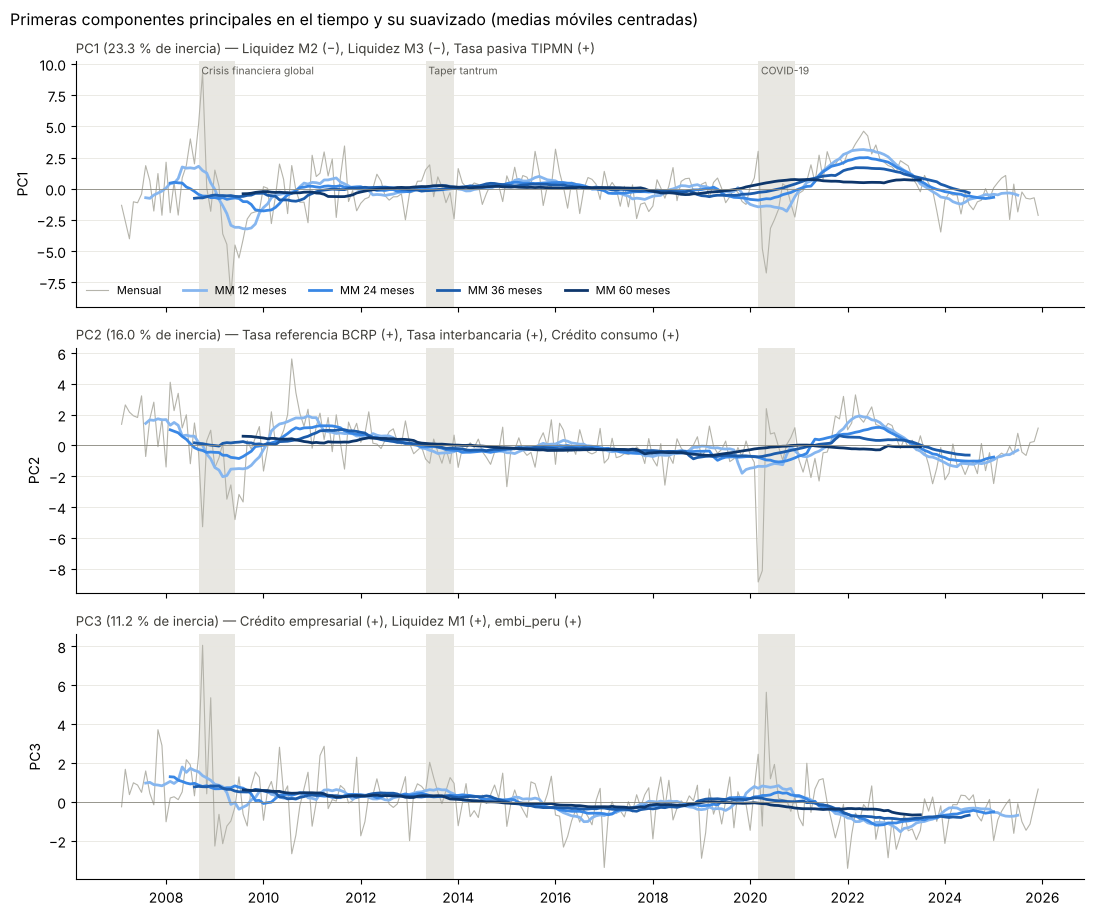

In [4]:
# Rampa ordinal de un solo tono (ventana más larga = más oscura)
AZULES = ['#86b6ef', '#3987e5', '#1c5cab', '#0d366b']
GRIS = '#b5b4ab'

def sombrear(ax, etiquetas=False):
    for nombre, (ini, fin) in EPISODIOS_REFERENCIA.items():
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fin), color='#d9d8d0', alpha=0.6, lw=0, zorder=0)
        if etiquetas:
            ax.annotate(nombre, (pd.Timestamp(ini), 1.0), xycoords=('data', 'axes fraction'),
                        xytext=(2, -2), textcoords='offset points', fontsize=7.5,
                        color='#5f5e58', va='top')

def interpretar(k):
    c = corr[f'PC{k+1}'].sort_values(key=np.abs, ascending=False).head(3)
    return ', '.join(f'{v} ({"+" if r > 0 else "−"})' for v, r in c.items())

fig, axes = plt.subplots(N_COMP, 1, figsize=(11, 3.1 * N_COMP), sharex=True)
for k, ax in enumerate(np.atleast_1d(axes)):
    col = f'PC{k+1}'
    sombrear(ax, etiquetas=(k == 0))
    ax.plot(scores_df.index, scores_df[col], color=GRIS, lw=0.8, label='Mensual')
    for w, color in zip(VENTANAS, AZULES):
        ax.plot(suavizados[w].index, suavizados[w][col], color=color, lw=2, label=f'MM {w} meses')
    ax.axhline(0, color='#8a8980', lw=0.6)
    ax.set_ylabel(col)
    ax.set_title(f'{col} ({100 * pca.explained_variance_ratio_[k]:.1f} % de inercia) — {interpretar(k)}',
                 loc='left', fontsize=9.5, color='#3d3c37')
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.grid(axis='y', color='#e8e7e0', lw=0.6)
np.atleast_1d(axes)[0].legend(ncol=5, fontsize=8, loc='lower left', frameon=False)
fig.suptitle('Primeras componentes principales en el tiempo y su suavizado (medias móviles centradas)',
             x=0.01, ha='left', fontsize=11.5)
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/05b_componentes_suavizadas.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Centrada vs. causal: el costo del tiempo real

Con la media móvil **causal** (solo meses pasados) el indicador puede calcularse en tiempo
real, pero sus giros llegan tarde. El gráfico compara ambas para la ventana de 12 meses.

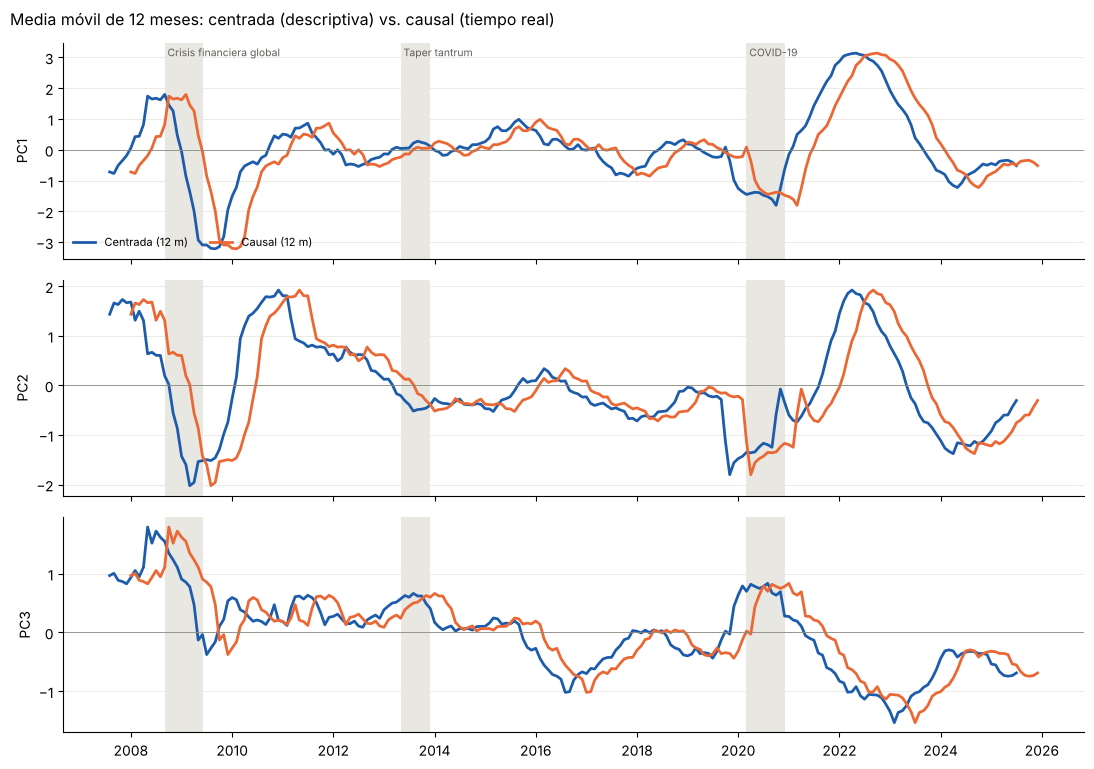

PC1: la versión causal llega con ~5 meses de retraso (corr. 1.000)
PC2: la versión causal llega con ~5 meses de retraso (corr. 1.000)
PC3: la versión causal llega con ~5 meses de retraso (corr. 1.000)


In [5]:
W = 12
fig, axes = plt.subplots(N_COMP, 1, figsize=(11, 2.6 * N_COMP), sharex=True)
for k, ax in enumerate(np.atleast_1d(axes)):
    col = f'PC{k+1}'
    sombrear(ax, etiquetas=(k == 0))
    ax.plot(suavizados[W].index, suavizados[W][col], color='#1c5cab', lw=2, label=f'Centrada ({W} m)')
    ax.plot(causales[W].index, causales[W][col], color='#eb6834', lw=2, label=f'Causal ({W} m)')
    ax.axhline(0, color='#8a8980', lw=0.6)
    ax.set_ylabel(col)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.grid(axis='y', color='#e8e7e0', lw=0.6)
np.atleast_1d(axes)[0].legend(fontsize=8, loc='lower left', frameon=False, ncol=2)
fig.suptitle(f'Media móvil de {W} meses: centrada (descriptiva) vs. causal (tiempo real)',
             x=0.01, ha='left', fontsize=11.5)
plt.tight_layout()
plt.savefig('reports/figures/05b_centrada_vs_causal.png', dpi=130, bbox_inches='tight')
plt.show()

# Retraso de la versión causal: desplazamiento que maximiza la correlación con la centrada
for k in range(N_COMP):
    col = f'PC{k+1}'
    a, b = suavizados[W][col], causales[W][col]
    mejores = {r: a.corr(b.shift(-r)) for r in range(0, 13)}
    r = max(mejores, key=mejores.get)
    print(f'{col}: la versión causal llega con ~{r} meses de retraso (corr. {mejores[r]:.3f})')

## 6. Persistencia según la ventana

¿Qué tan estable es cada componente suavizada? Se mide por el número de **cambios de signo**
(cruces de cero): menos cruces = señal más persistente, más cercana a la noción de fase.

In [6]:
filas = []
for w in [1] + VENTANAS:
    serie = scores_df if w == 1 else suavizados[w]
    fila = {'ventana_meses': w}
    for c in scores_df.columns:
        s = np.sign(serie[c].dropna())
        fila[f'cruces_{c}'] = int((s.diff().abs() > 0).sum())
    filas.append(fila)
persistencia = pd.DataFrame(filas).set_index('ventana_meses')
persistencia.to_csv('data/results/05b_persistencia.csv')
persistencia

,cruces_PC1,cruces_PC2,cruces_PC3
ventana_meses,,,
1,72,86,87
12,18,7,13
24,9,5,5
36,8,5,3
60,3,3,5


## 7. Lectura (dataset corregido, 227 meses)

1. **Orientación de los ejes (regla de Rcamiz).** PC1 se invirtió por un margen mínimo
   (cargas negativas 0,505 frente a positivas 0,495). La regla es determinística, pero en un
   empate tan cercano un pequeño cambio en los datos puede voltear el eje: hay que reportar
   el signo junto con este margen.
2. **PC1 (23,3 %) — condiciones monetario-financieras.** Valores positivos = tasas pasivas e
   interbancaria altas con menor crecimiento de liquidez (M2, M3) y de la bolsa. El suavizado
   muestra un único episodio persistente fuerte: **2021–2023**, coherente con el ciclo de
   alza de la tasa de referencia posterior a la pandemia [verificar fechas con el BCRP].
3. **PC2 (16,0 %) — tasas de política y actividad.** Caídas pronunciadas en **2008–2009** y
   **2020** (recortes de tasa y caída de la actividad) y un máximo en **2022**.
4. **PC3 (11,2 %) — crédito empresarial y riesgo.** Tendencia descendente de largo plazo
   (de ≈ +1 en 2008 a ≈ −1 en 2023), con un repunte en **2020** que podría reflejar los
   programas de crédito empresarial con garantía estatal de ese año [hipótesis por verificar].
5. **Qué ventana usar.** Los cruces de cero bajan de 72–87 (mensual) a 7–18 con 12 meses y a
   5–9 con 24 meses. Con 60 meses las series quedan casi planas: se pierde la señal de los
   episodios. Las ventanas de **12 a 24 meses** equilibran ruido y señal; la de 12 es la que
   se usa como referencia para la datación de regímenes en `09`.
6. **Centrada vs. causal.** La media causal de 12 meses llega con unos 5 meses de retraso
   (≈ (w − 1)/2). Para describir episodios se usa la centrada; para un indicador en tiempo
   real, la causal, asumiendo ese retraso.
7. **Limitación.** La muestra cubre 19 años; un ciclo financiero de 8 a 30 años
   (Drehmann, Borio & Tsatsaronis, 2012) no se observa completo. La extensión hacia 1985
   (`01b`, `04c`) es necesaria para leer ciclos de mediano plazo.